<a href="https://colab.research.google.com/github/MohtadiIbtesum/cse422_project/blob/main/attrition_project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction
### CSE422 Project — Supervised Learning (Logistic Regression, Naive Bayes, Neural Network) + Unsupervised Learning (K-Means)

**How to run:** In Google Colab, `Runtime > Run all`. The first code cell will prompt you to upload `4.csv` — do that when asked, then let the rest of the notebook run top to bottom.

**What this notebook does, in order:**
1. Loads and explores the dataset (EDA)
2. Cleans and preprocesses the data (nulls, encoding, scaling, PCA)
3. Trains three supervised models — Logistic Regression, Naive Bayes, a Neural Network — plus K-Means as the unsupervised model
4. Evaluates and compares every model
5. Tests the trained models on 10 synthetic "current employee" profiles
6. Lets you **download every result table and every plot** as files at the end, so you can attach them to your report

### Table of Contents
0. Setup & Upload Dataset
1. Introduction
2. Dataset Description
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training (Supervised + Unsupervised)
6. Model Evaluation
7. Testing on Synthetic Employees
8. Conclusion
9. Download Results

## 0. Setup & Upload Dataset

Run the cell below and select `4.csv` (the IBM HR Analytics Attrition dataset) when the upload button appears.

In [42]:
from google.colab import files
uploaded = files.upload()  # upload 4.csv when prompted

Saving 4.csv to 4 (2).csv
Saving 4_test.csv to 4_test (1).csv


In [43]:
# Core data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample

# Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Neural network (Keras/TensorFlow — same library used in the Neural Network lab)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Unsupervised model
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, silhouette_score,
                              adjusted_rand_score)

sns.set_style('whitegrid')
np.random.seed(45)
tf.random.set_seed(45)

# Folder where every table/plot we want to hand in gets saved
import os
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
saved_files = []  # we append every file we produce here so Section 9 can zip & download them all

def save_fig(fig, name):
    # Save a matplotlib figure into OUTPUT_DIR and remember it for download
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=300)
    saved_files.append(path)
    return path

def save_table(df, name):
    # Save a DataFrame as CSV into OUTPUT_DIR and remember it for download
    path = os.path.join(OUTPUT_DIR, name)
    df.to_csv(path)
    saved_files.append(path)
    return path

## 1. Introduction

**Supervised vs. unsupervised learning, in one line:** supervised models learn from data that already has the answer attached (here, `Attrition` = did this employee actually leave?), while unsupervised models look for structure in the data *without* being told the answer. This project uses both: supervised models to directly predict attrition, and K-Means (unsupervised) to check whether employees naturally group into clusters that line up with attrition on their own.

**Target feature:** `Attrition` — binary: `1` = employee has left the company, `0` = employee is still with the company.

**Problem & motivation:** Employee turnover is expensive — every employee who leaves costs a company money and time in recruiting, onboarding, and lost productivity. If HR can identify which *current* employees look statistically similar to past employees who left, they can intervene early (better pay, workload changes, career development) before losing them.

**What we build:**
| # | Model | Type | Why it's here |
|---|-------|------|----------------|
| 1 | Logistic Regression | Supervised | Simple, interpretable linear baseline |
| 2 | Naive Bayes | Supervised | Fast probabilistic baseline; assumes features are independent |
| 3 | Neural Network (Keras) | Supervised | Learns non-linear feature interactions |
| 4 | K-Means | Unsupervised | Checks if attrition is the *natural* grouping in the data, without using the label |

## 2. Dataset Description

In [44]:
df = pd.read_csv('4.csv')
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1677, 35)


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,Male,42,3,1,Laboratory Technician,4,Married,2596,5099,1,Y,Yes,13,3,2,80,1,10,2,3,10,0,7,8,0
1,1,35,Travel_Rarely,921,Sales,8,3,Other,1,1,Male,46,3,1,Sales Representative,1,Married,2899,10778,1,Y,No,17,3,4,80,1,4,3,3,4,2,0,3,0
2,2,32,Travel_Rarely,718,Sales,26,3,Marketing,1,3,Male,80,3,2,Sales Executive,4,Divorced,4627,16495,0,Y,No,17,3,4,80,2,4,3,3,3,2,1,2,0
3,3,38,Travel_Rarely,1488,Research & Development,2,3,Medical,1,3,Female,40,3,2,Healthcare Representative,1,Married,5347,13384,3,Y,No,14,3,3,80,0,15,1,1,6,0,0,2,0
4,4,50,Travel_Rarely,1017,Research & Development,5,4,Medical,1,2,Female,37,3,5,Manager,1,Single,19033,19805,1,Y,Yes,13,3,3,80,0,31,0,3,31,14,4,10,1


In [45]:
print("Number of data points:", df.shape[0])
print("Number of features (excluding target):", df.shape[1] - 1)
print()
print("Feature dtypes:")
print(df.dtypes.value_counts())
print()
print("Categorical (object/string) columns:")
print(df.select_dtypes(include='object').columns.tolist())
print()
print("Numeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Number of data points: 1677
Number of features (excluding target): 34

Feature dtypes:
int64     27
object     8
Name: count, dtype: int64

Categorical (object/string) columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numeric columns:
['id', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']


**Why check unique values below?** A column that only ever holds *one* value (e.g. every row says `Y`) carries zero information — no model can learn anything from a feature that never changes, so these are safe to drop later in preprocessing.

In [46]:
for c in ['EmployeeCount', 'Over18', 'StandardHours']:
    print(c, '-> unique values:', df[c].unique())

EmployeeCount -> unique values: [1]
Over18 -> unique values: ['Y']
StandardHours -> unique values: [80]


## 3. Exploratory Data Analysis (EDA)

Before touching any model, we look at the raw data to understand what patterns already exist and how imbalanced the target is.

Attrition
0    1477
1     200
Name: count, dtype: int64


/tmp/ipykernel_1504/3243499660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette=['#4C72B0', '#DD8452'])


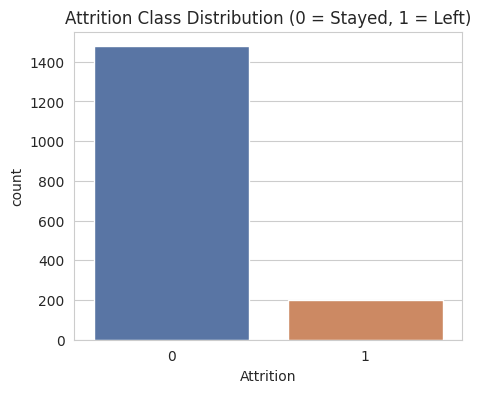

Attrition rate: 11.9% of employees left


In [47]:
attr_counts = df['Attrition'].value_counts()
print(attr_counts)

fig = plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Attrition Class Distribution (0 = Stayed, 1 = Left)')
save_fig(fig, '01_attrition_class_distribution.png')
plt.show()
print(f"Attrition rate: {attr_counts[1] / len(df) * 100:.1f}% of employees left")

**Note this number.** It comes back in Section 4 — it's the reason we can't just look at accuracy later.

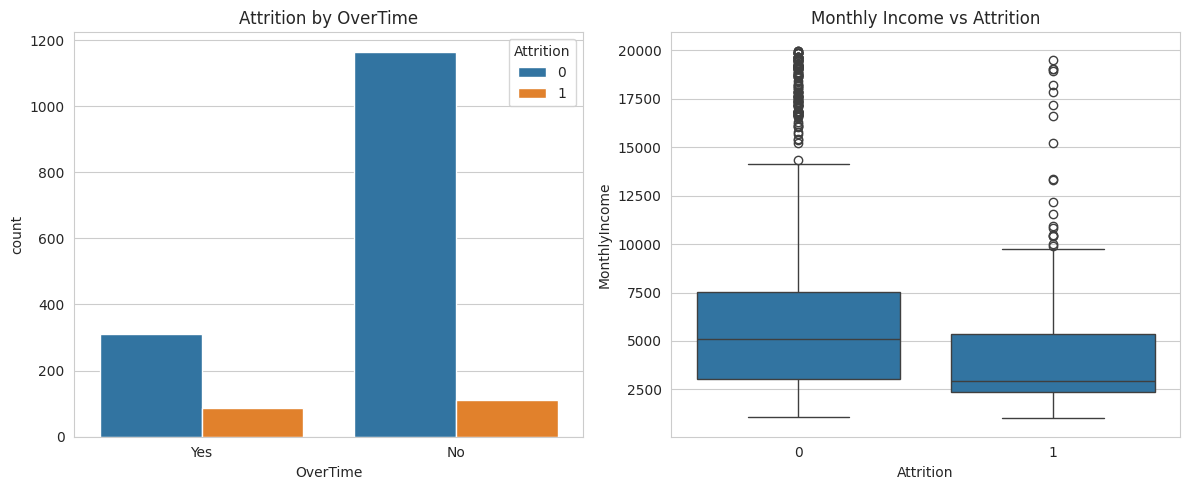

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='OverTime', hue='Attrition', data=df, ax=axes[0])
axes[0].set_title('Attrition by OverTime')
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1])
axes[1].set_title('Monthly Income vs Attrition')
plt.tight_layout()
save_fig(fig, '02_overtime_and_income_vs_attrition.png')
plt.show()

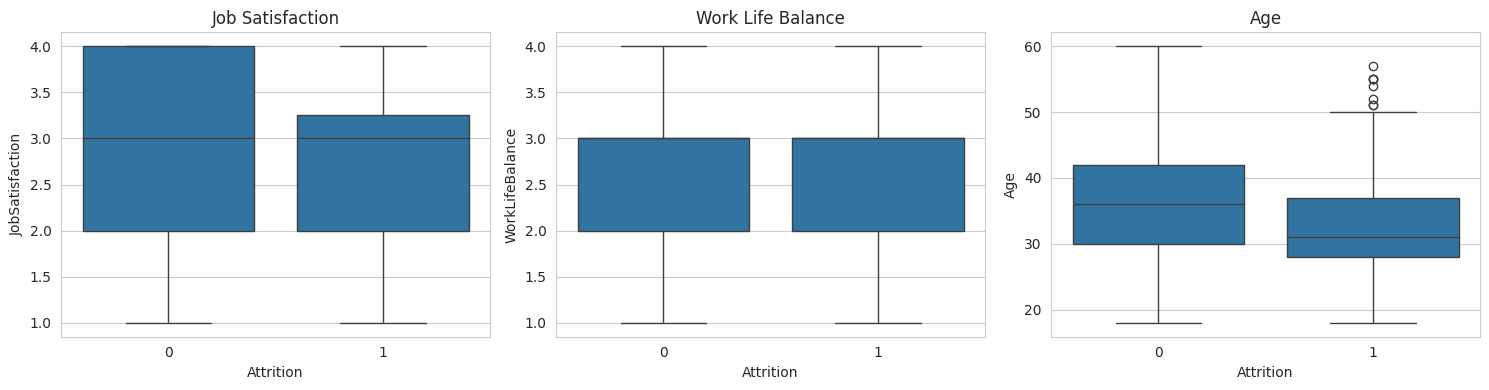

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df, ax=axes[0])
sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df, ax=axes[1])
sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[2])
axes[0].set_title('Job Satisfaction')
axes[1].set_title('Work Life Balance')
axes[2].set_title('Age')
plt.tight_layout()
save_fig(fig, '03_satisfaction_worklife_age_vs_attrition.png')
plt.show()

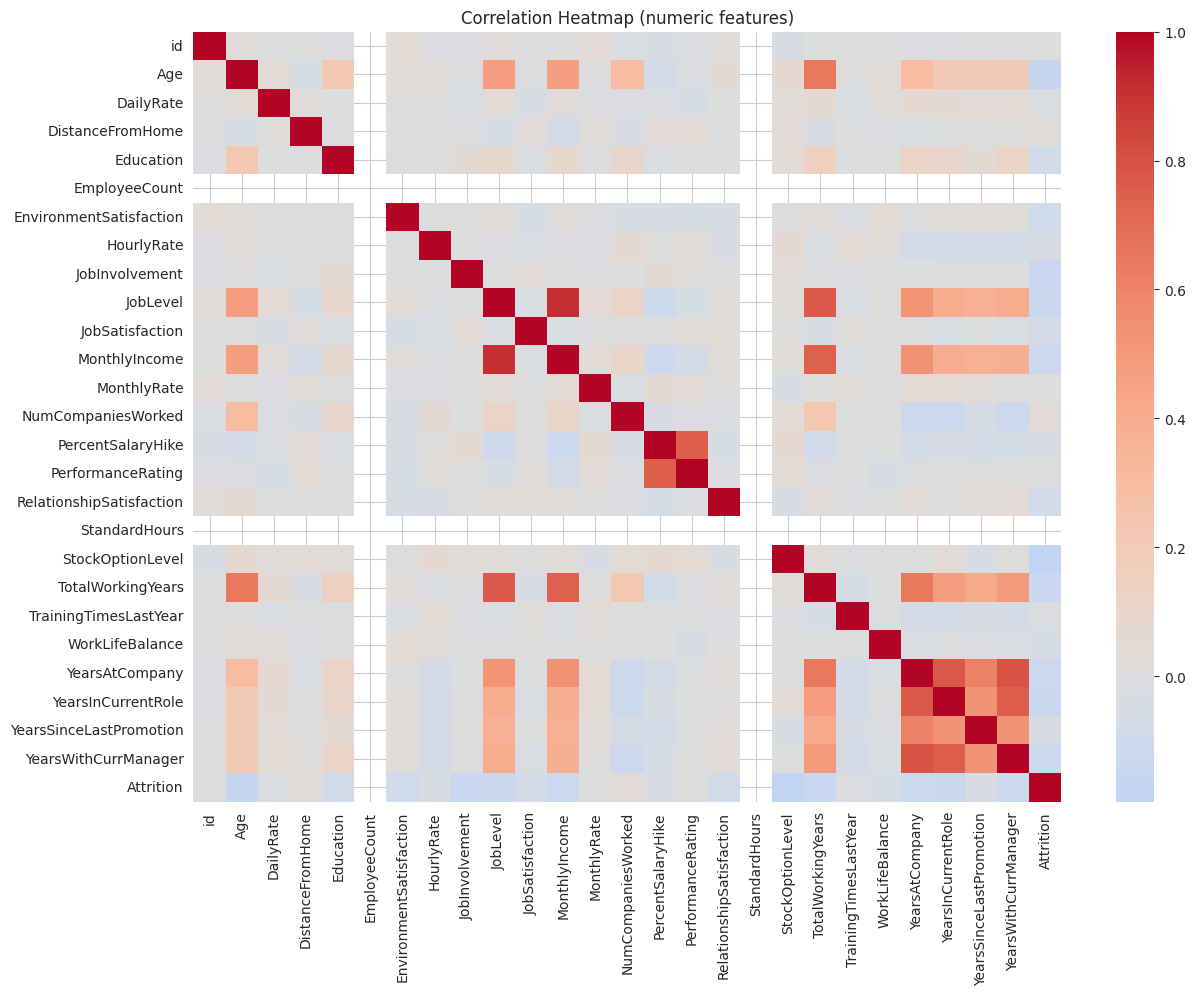

In [50]:
fig = plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric features)')
save_fig(fig, '04_correlation_heatmap.png')
plt.show()

Department
Human Resources           0.179487
Sales                     0.142251
Research & Development    0.107969
Name: Attrition, dtype: float64


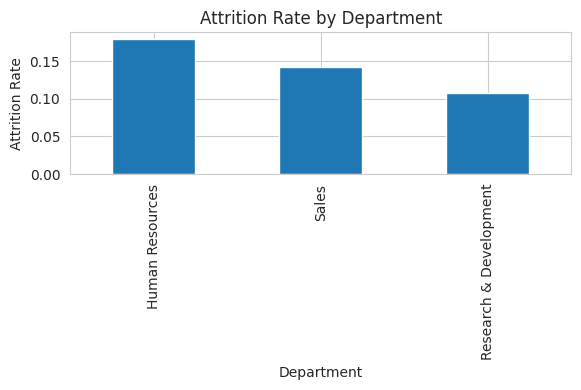

In [51]:
attr_by_dept = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)
print(attr_by_dept)
fig = plt.figure(figsize=(6,4))
attr_by_dept.plot(kind='bar', title='Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.tight_layout()
save_fig(fig, '05_attrition_rate_by_department.png')
plt.show()

## 4. Data Preprocessing

**The imbalance problem:** as seen in Section 3, far more employees stayed than left (roughly 88% vs 12%). A model that *always* predicts "Stayed" would score ~88% accuracy while being completely useless to HR. We handle this two ways later on:
- `class_weight='balanced'` for Logistic Regression, and a matching `class_weight` for the Neural Network, so misclassifying a "Left" employee is penalized more than misclassifying a "Stayed" one.
- Looking at **Precision / Recall / F1 / AUC**, not just Accuracy, in Section 6.

Preprocessing itself follows the standard pipeline: drop useless columns → handle nulls/duplicates → encode categoricals → select/inspect features → split + scale → (optionally) reduce dimensionality with PCA.

### 4.1 Drop uninformative columns

`EmployeeCount`, `Over18`, and `StandardHours` were shown in Section 2 to hold a single constant value across every row — dropping them is safe and lossless. `id` is just a row identifier, not a real feature.

In [52]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Dropped columns:", drop_cols)
print("Remaining shape:", df_clean.shape)

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'id']
Remaining shape: (1677, 31)


### 4.2 Handle null and duplicate values

Two common ways to deal with missing values are (a) **dropping** rows/columns that have them, which is safe when only a small fraction of rows are affected, or (b) **imputing** a value (e.g. the column mean, via `SimpleImputer`) when a useful column has a few gaps. We check below which situation we're in for this dataset before deciding.

In [53]:
null_counts = df_clean.isnull().sum()
print("Nulls per column:\n", null_counts[null_counts > 0] if null_counts.sum() > 0 else "None")
print("Duplicate rows:", df_clean.duplicated().sum())

before = len(df_clean)
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()
print(f"Rows dropped: {before - len(df_clean)} -> remaining: {len(df_clean)}")

Nulls per column:
 None
Duplicate rows: 0
Rows dropped: 0 -> remaining: 1677


### 4.3 Encode categorical values

Categorical columns need to become numbers before any of these models can use them. There are two standard options:
- **Label Encoding** (`LabelEncoder`) — assigns each category an integer (0, 1, 2, ...). Simple and compact, but implies an order/ranking between categories that may not really exist.
- **One-Hot Encoding** (`pd.get_dummies`) — creates a separate 0/1 column per category. No false ordering, but adds many columns for high-cardinality features.

Most columns here (`BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`) are nominal (no real order), so one-hot encoding is the "more correct" choice in theory. We use **Label Encoding** here instead because it keeps the feature count small (important for the synthetic-employee test in Section 7, and for readability of the correlation table in 4.4) and all three models we use (Logistic Regression, Naive Bayes, Neural Network) can still learn from label-encoded input — it's a reasonable trade-off, not a hard requirement. If you want to compare, try swapping in `pd.get_dummies` and re-running from here.

In [54]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Define your target variable
target_col = 'Attrition'

# 2. Identify categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# 3. Handle the target variable separately (Label Encoding is best for the target)
if target_col in cat_cols:
    cat_cols.remove(target_col)
    le = LabelEncoder()
    df_clean[target_col] = le.fit_transform(df_clean[target_col])

# 4. Apply One-Hot Encoding ONLY to the feature columns
# drop_first=True prevents multicollinearity (the dummy variable trap)
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# 5. Define your features (X) and target (y)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Display the updated dataframe
display(df_clean.head())

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,36,599,24,3,4,42,3,1,4,2596,5099,1,13,3,2,1,10,2,3,10,0,7,8,0,True,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,True
1,35,921,8,3,1,46,3,1,1,2899,10778,1,17,3,4,1,4,3,3,4,2,0,3,0,False,True,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,True,False,False
2,32,718,26,3,3,80,3,2,4,4627,16495,0,17,3,4,2,4,3,3,3,2,1,2,0,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
3,38,1488,2,3,3,40,3,2,1,5347,13384,3,14,3,3,0,15,1,1,6,0,0,2,0,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,50,1017,5,4,2,37,3,5,1,19033,19805,1,13,3,3,0,31,0,3,31,14,4,10,1,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True


### 4.4 Feature selection — correlation with the target

Features most (positively or negatively) correlated with `Attrition` are the ones most likely to matter for the model. We keep all features for training below (dropping weak ones is optional — see the commented line), but this ranking is useful on its own for the write-up: it tells you *what HR should actually look at*.

StockOptionLevel                   -0.194018
MaritalStatus_Single                0.175006
OverTime_Yes                        0.173965
Age                                -0.161044
JobRole_Sales Representative        0.147832
JobInvolvement                     -0.139929
TotalWorkingYears                  -0.138740
JobLevel                           -0.137238
YearsInCurrentRole                 -0.133466
YearsAtCompany                     -0.127120
MonthlyIncome                      -0.126896
YearsWithCurrManager               -0.124712
JobRole_Manufacturing Director     -0.105233
BusinessTravel_Travel_Frequently    0.100865
JobRole_Laboratory Technician       0.097516
Name: Attrition, dtype: float64


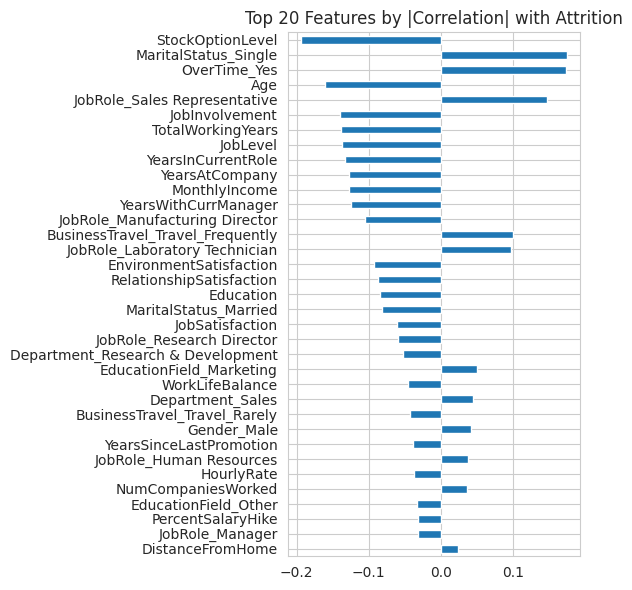

In [55]:
X_full = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

corr_with_target = df_clean.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print(corr_with_target.head(15))

fig = plt.figure(figsize=(6,6))
corr_with_target.head(35).plot(kind='barh')
plt.title('Top 20 Features by |Correlation| with Attrition')
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, '06_top_correlated_features.png')
plt.show()

feature_cols = X_full.columns.tolist()  # keeping all features; uncomment below for a leaner model
# feature_cols = corr_with_target.head(15).index.tolist()
X = X_full[feature_cols]

### 4.5 Train/test split (stratified) + feature scaling

We split **before** scaling and fit the scaler only on the training data, then apply it to the test data — fitting on the full dataset would leak test-set information into training. The split is **stratified** on `y` so both the train and test sets keep the same ~88/12 class balance seen in Section 3.

**Why scale at all?** Logistic Regression and Neural Networks are sensitive to feature magnitude — a column like `MonthlyIncome` (values in the thousands) would dominate a column like `JobSatisfaction` (values 1–4) purely because of its scale, not because it's actually more important. `StandardScaler` rescales every feature to mean 0, standard deviation 1 so they contribute fairly. The quick before/after check below shows this isn't just theoretical.

In [56]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize MinMaxScaler instead of StandardScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (1341, 44)  Test shape: (336, 44)


In [57]:
# Quick before/after demonstration: does scaling actually help here?
lr_unscaled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_unscaled.fit(X_train, y_train)
f1_unscaled = f1_score(y_test, lr_unscaled.predict(X_test))

lr_scaled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_scaled.fit(X_train_scaled, y_train)
f1_scaled = f1_score(y_test, lr_scaled.predict(X_test_scaled))

print(f"Logistic Regression F1 — unscaled features: {f1_unscaled:.3f}")
print(f"Logistic Regression F1 — scaled features:   {f1_scaled:.3f}")
print("(This is a quick sanity check only — the actual models trained below all use the scaled features.)")


Logistic Regression F1 — unscaled features: 0.340
Logistic Regression F1 — scaled features:   0.391
(This is a quick sanity check only — the actual models trained below all use the scaled features.)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data to prevent data leakage
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print("New training target distribution after SMOTE:")
print(y_train.value_counts())

New training target distribution after SMOTE:
Attrition
0    1181
1    1181
Name: count, dtype: int64


### 4.6 Optional feature engineering: PCA for dimensionality reduction

Several features move together (e.g. `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`), so some correlation was already visible in the heatmap in Section 3. PCA can compress the correlated features into a smaller set of uncorrelated components while keeping most of the variance. We fit PCA on the **scaled training data only** (never on test data — same leakage concern as scaling above), pick the number of components that explains ~90% of variance, and keep both the original and PCA-reduced feature sets so models can be compared on each in Section 6.2.

Components needed to explain 90% of variance: 21 (out of 44 original features)


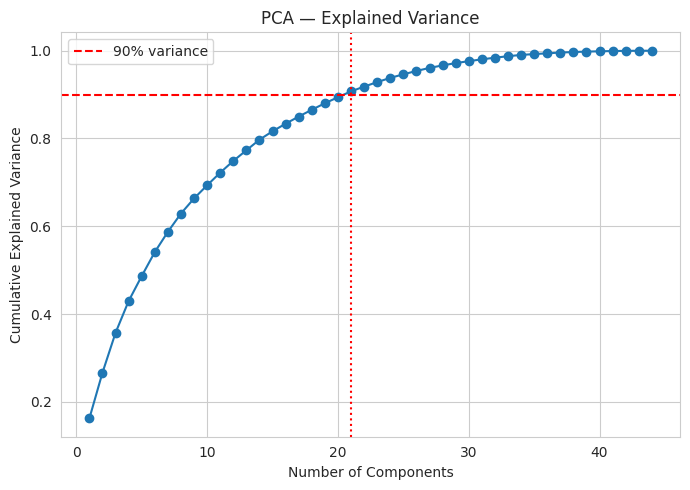

Reduced train shape: (2362, 21)


In [59]:
pca_fs = PCA(random_state=42)
pca_fs.fit(X_train_scaled)

cum_var = np.cumsum(pca_fs.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components needed to explain 90% of variance: {n_components_90} (out of {X_train_scaled.shape[1]} original features)")

fig = plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.axvline(n_components_90, color='red', linestyle=':')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance')
plt.legend()
plt.tight_layout()
save_fig(fig, '07_pca_explained_variance.png')
plt.show()

pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)
print("Reduced train shape:", X_train_pca.shape)

## 5. Model Training

Three supervised models — Logistic Regression, Naive Bayes, and a Neural Network — plus K-Means for the unsupervised part in Section 5.2.

### 5.1 Supervised models

**Logistic Regression** and **Naive Bayes** train directly on the scaled features. `class_weight='balanced'` in Logistic Regression automatically re-weights the loss so the minority ("Left") class isn't ignored — Naive Bayes has no such parameter in scikit-learn, so we leave it as-is for comparison and discuss the difference in Section 8.

**Neural Network — how it works, briefly:** a feed-forward network is a stack of layers; each layer computes $Z^{[l]} = W^{[l]}A^{[l-1]} + B^{[l]}$ then applies a non-linear activation $A^{[l]} = f(Z^{[l]})$. Training uses **backpropagation**: the error at the output layer is computed from a loss function, then propagated backward layer by layer via the chain rule to get the gradient of every weight, which an optimizer (here, Adam — a smarter variant of gradient descent) uses to update the weights. We implement this with **Keras/TensorFlow** rather than by hand:

- Two hidden `Dense` layers (32 then 16 units, `relu` activation) to learn non-linear feature interactions
- One output `Dense(1, activation='sigmoid')` layer, since this is binary classification
- `Adam` optimizer + `BinaryCrossentropy` loss (the standard choice for binary classification)
- `class_weight` passed to `.fit()` — Keras's own re-weighting mechanism, equivalent in spirit to `class_weight='balanced'` above, so we don't need to manually oversample the minority class

In [60]:
# 1. Reset the models dictionary so it ONLY contains Scikit-Learn models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 10}, random_state=42)
}

trained = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    # 1. Train the model
    model.fit(X_train_scaled, y_train)
    trained[name] = model

    # 2. Get probabilities
    probs = model.predict_proba(X_test_scaled)[:, 1]
    probabilities[name] = probs

    # 3. Save predictions (with threshold optimization for Random Forest)
    if name == 'Random Forest':
        best_f1 = 0
        best_thresh = 0.5

        # Test thresholds from 0.10 to 0.90 in increments of 0.05
        for thresh in np.arange(0.1, 0.9, 0.05):
            temp_preds = (probs >= thresh).astype(int)
            temp_f1 = f1_score(y_test, temp_preds)

            if temp_f1 > best_f1:
                best_f1 = temp_f1
                best_thresh = thresh

        print(f"Optimal Threshold for {name}: {best_thresh:.2f}")
        predictions[name] = (probs >= best_thresh).astype(int)

    else:
        # Standard prediction for Logistic Regression and Naive Bayes
        predictions[name] = model.predict(X_test_scaled)

    print(f"{name} trained.")

Logistic Regression trained.
Naive Bayes trained.
Optimal Threshold for Random Forest: 0.30
Random Forest trained.


In [61]:
from sklearn.model_selection import cross_val_score

print("--- 5-Fold Cross Validation (Training Data) ---")
cv_scores = {}

# We only run this easily on Scikit-Learn models.
# Keras neural networks require a specialized wrapper for sklearn's cross_val_score.
for name in ['Logistic Regression', 'Naive Bayes']:
    model = models[name]
    # Run 5-fold CV on the training data
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores

    print(f"{name}:")
    print(f"  All 5 folds: {np.round(scores, 3)}")
    print(f"  Average Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})\n")

--- 5-Fold Cross Validation (Training Data) ---
Logistic Regression:
  All 5 folds: [0.801 0.835 0.833 0.79  0.811]
  Average Accuracy: 0.814 (+/- 0.017)

Naive Bayes:
  All 5 folds: [0.649 0.681 0.663 0.729 0.716]
  Average Accuracy: 0.688 (+/- 0.030)



In [62]:
# Neural Network (Keras)
# class_weight re-balances the loss so the minority ('Left') class isn't ignored,
# without needing to manually oversample like a plain MLP without this option would.
n_features = X_train_scaled.shape[1]
class_weight = {
    0: 1.0,
    1: (y_train == 0).sum() / (y_train == 1).sum()  # weight the minority class by the imbalance ratio
}
print("Class weights used:", class_weight)

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(n_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

nn_history = nn_model.fit(X_train_scaled, y_train,
                           validation_split=0.15,
                           epochs=60,
                           batch_size=32,
                           class_weight=class_weight,
                           verbose=0)

nn_proba = nn_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

trained['Neural Network (Keras)'] = nn_model
predictions['Neural Network (Keras)'] = nn_pred
probabilities['Neural Network (Keras)'] = nn_proba
models['Neural Network (Keras)'] = nn_model  # so it shows up alongside the others below

print("Neural Network (Keras) trained.")

Class weights used: {0: 1.0, 1: np.float64(1.0)}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network (Keras) trained.


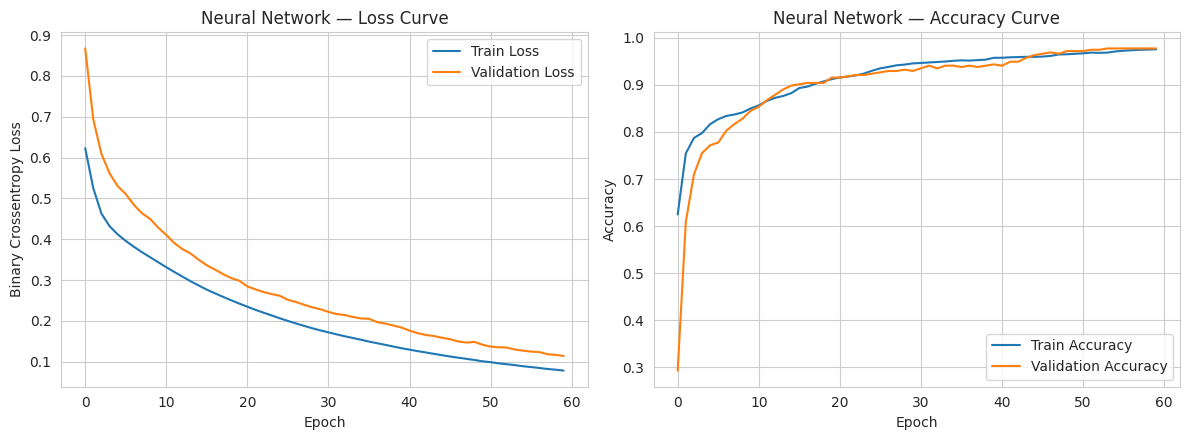

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(nn_history.history['loss'], label='Train Loss')
axes[0].plot(nn_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Neural Network — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()

axes[1].plot(nn_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(nn_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Neural Network — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '08_nn_training_curves.png')
plt.show()

### 5.2 Unsupervised: K-Means Clustering

**Step 1 — how many clusters?** Before picking a `k`, the **Elbow Method** plots the within-cluster sum of squared distances (`inertia_`) against `k`. As `k` increases inertia always drops, but the *rate* of improvement slows down — the "elbow" in the curve is a reasonable, data-driven choice for `k` (as opposed to just guessing).

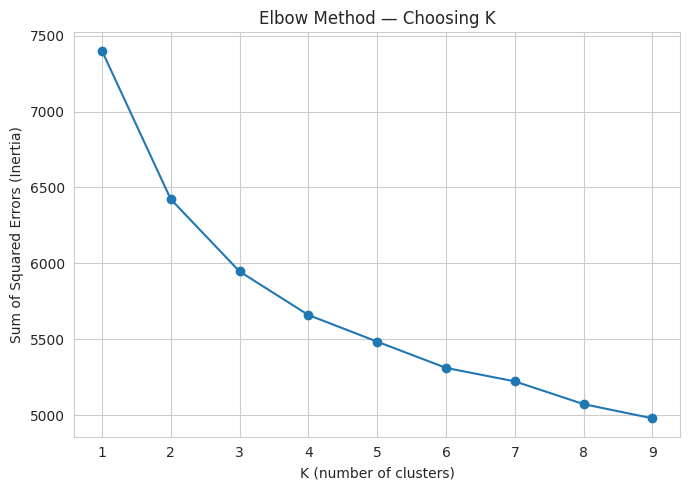

In [64]:
X_all_scaled = scaler.transform(X)  # cluster on the full dataset, unsupervised (no y used)

k_range = range(1, 10)
sse = []
for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_elbow.fit(X_all_scaled)
    sse.append(km_elbow.inertia_)

fig = plt.figure(figsize=(7,5))
plt.plot(list(k_range), sse, marker='o')
plt.xlabel('K (number of clusters)')
plt.ylabel('Sum of Squared Errors (Inertia)')
plt.title('Elbow Method — Choosing K')
plt.tight_layout()
save_fig(fig, '09_elbow_method.png')
plt.show()

**Step 2 — fit K-Means.** Since our target is binary, `k=2` is the natural comparison point; `k=3` is included too in case a 3-way split fits the data better than the elbow plot alone suggests. Points are projected to 2D via PCA purely for visualization — the clustering itself is still done on all scaled features.

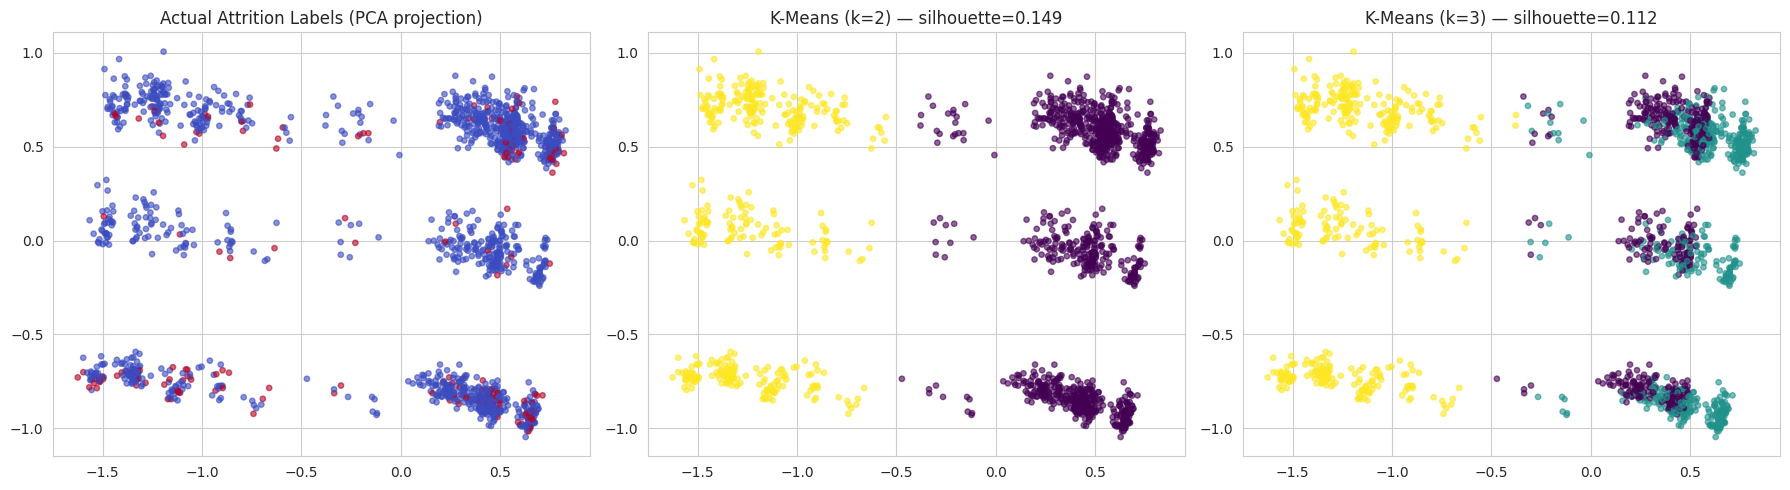

k=2: silhouette score = 0.149
k=3: silhouette score = 0.112


In [65]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca = pca_viz.fit_transform(X_all_scaled)

kmeans_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# True labels for reference (not used to fit the clustering, only to visualize alongside)
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.6, s=15)
axes[0].set_title('Actual Attrition Labels (PCA projection)')

for i, k in enumerate([2, 3], start=1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_all_scaled)
    sil = silhouette_score(X_all_scaled, labels)
    kmeans_results[k] = {'model': km, 'labels': labels, 'silhouette': sil}

    axes[i].scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.6, s=15)
    axes[i].set_title(f'K-Means (k={k}) — silhouette={sil:.3f}')

plt.tight_layout()
save_fig(fig, '10_kmeans_clusters.png')
plt.show()

for k, r in kmeans_results.items():
    print(f"k={k}: silhouette score = {r['silhouette']:.3f}")

**Reading the silhouette score:** it measures how well-separated the clusters are (closer to 1 is better, near 0 means overlapping clusters). Comparing k=2 against k=3 — and against the elbow plot above — tells us whether the *natural* groupings in the data actually line up with who stayed vs. left, or whether attrition isn't the dominant pattern in the feature space at all. This gets checked directly against the true labels in Section 6.1.

## 6. Model Evaluation

In [66]:
eval_results = {}

for name in models:
    # Ensure y_pred is available for all models. If not in 'predictions', derive from 'probabilities'.
    if name not in predictions:
        # Assuming a default threshold of 0.5 for models where predictions were not explicitly stored
        y_pred = (probabilities[name] >= 0.5).astype(int)
        predictions[name] = y_pred # Store for consistency, though not strictly required for this cell.
    else:
        y_pred = predictions[name]

    y_proba = probabilities[name]
    eval_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(eval_results).T
print(results_df.round(3))
save_table(results_df, 'model_comparison_results.csv')

                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.753      0.269   0.625     0.376  0.776
Naive Bayes                0.491      0.142   0.650     0.233  0.659
Random Forest              0.818      0.302   0.400     0.344  0.735
Neural Network (Keras)     0.818      0.277   0.325     0.299  0.706


'results/model_comparison_results.csv'

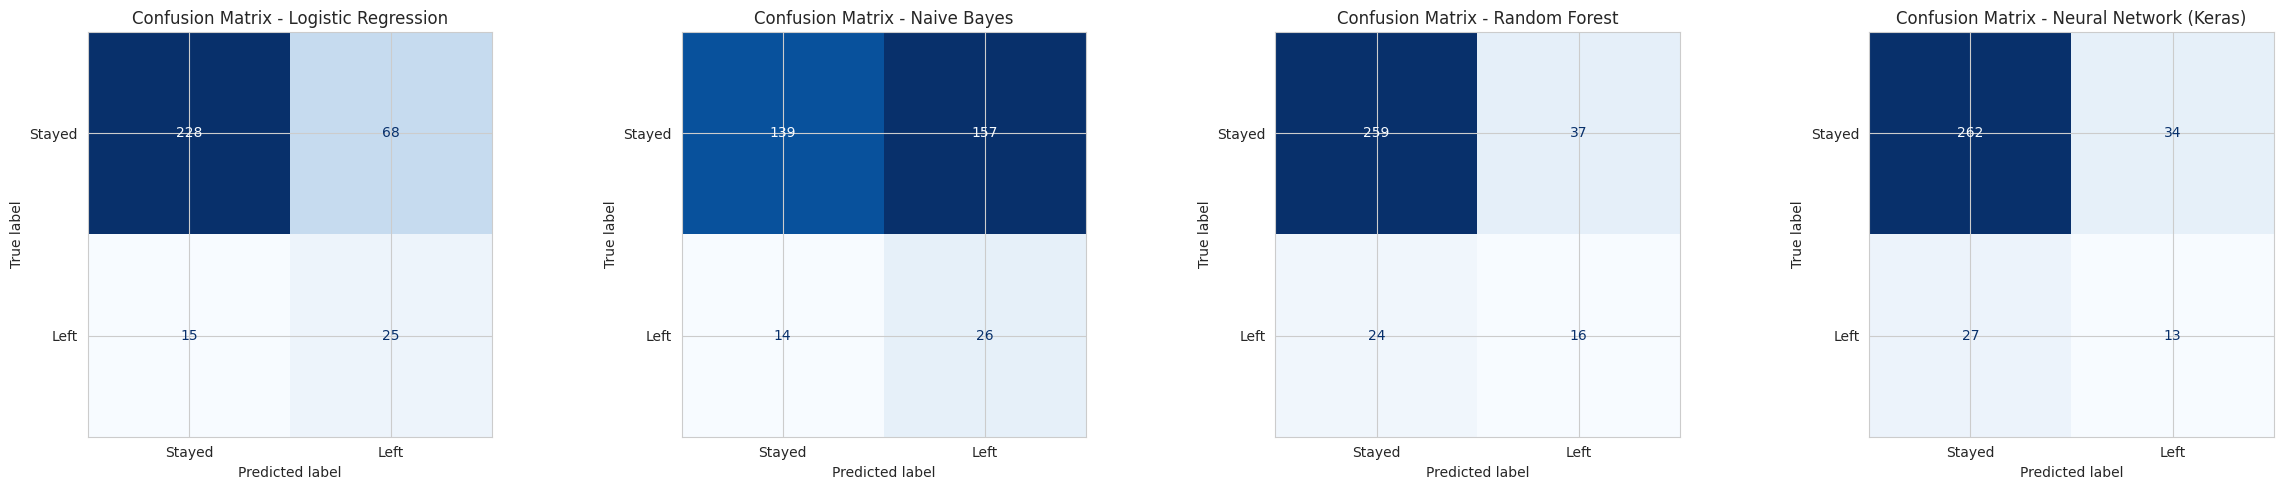

In [67]:
fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=['Stayed','Left']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
plt.tight_layout()
save_fig(fig, '11_confusion_matrices.png')
plt.show()

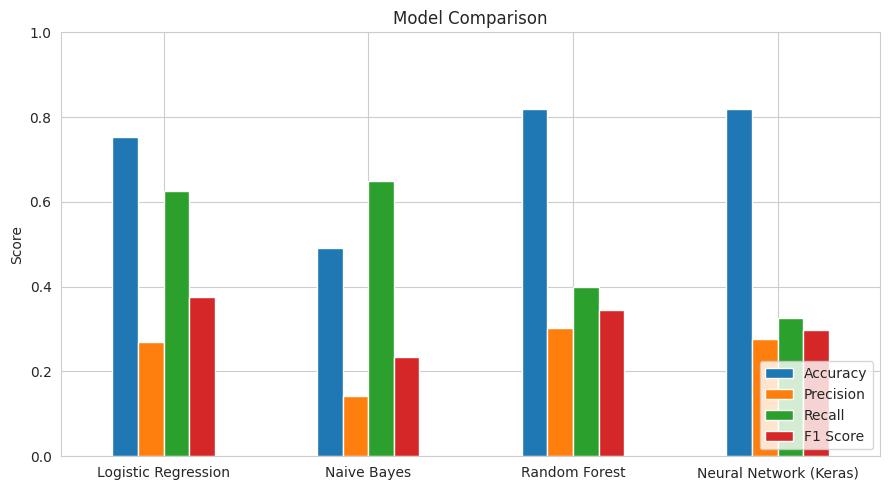

In [68]:
fig = plt.figure(figsize=(9,5))
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar', ax=plt.gca())
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '12_model_comparison_bar.png')
plt.show()

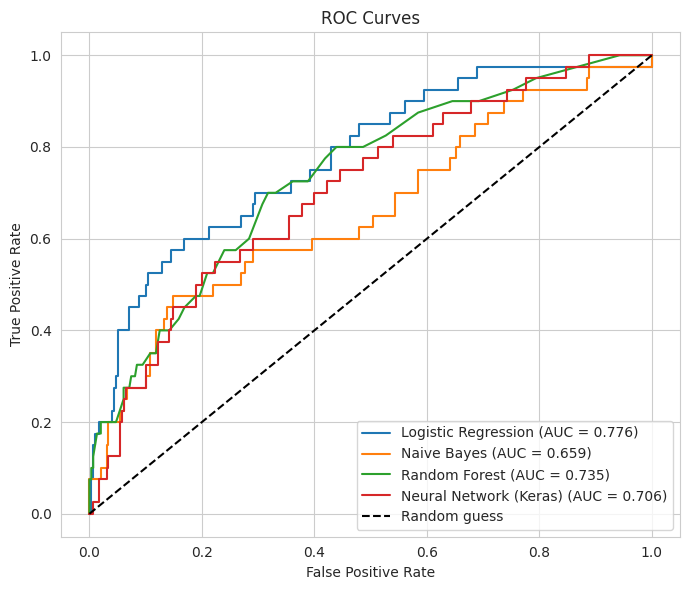

In [69]:
fig = plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = eval_results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '13_roc_curves.png')
plt.show()

### 6.1 Comparing K-Means clusters against the true Attrition label

The **Adjusted Rand Index (ARI)** measures agreement between the unsupervised cluster labels and the true `Attrition` labels — near 0 means the clusters don't correspond to attrition at all, near 1 means they line up almost perfectly. Expect this to be low: attrition is a subtle behavioral outcome, not necessarily the dominant structure in the raw feature space.

In [70]:
ari_results = {}
for k, r in kmeans_results.items():
    ari = adjusted_rand_score(y, r['labels'])
    ari_results[k] = ari
    print(f"k={k}: Adjusted Rand Index vs true Attrition label = {ari:.3f}")

ari_df = pd.DataFrame({'k': list(ari_results.keys()), 'Adjusted Rand Index': list(ari_results.values())})
save_table(ari_df, 'kmeans_ari_results.csv')

k=2: Adjusted Rand Index vs true Attrition label = 0.020
k=3: Adjusted Rand Index vs true Attrition label = 0.003


'results/kmeans_ari_results.csv'

### 6.2 Does PCA (dimensionality reduction) help or hurt?

Retrain the same three supervised models on the PCA-reduced features from Section 4.6 and compare F1/AUC against the full-feature versions above. The Neural Network is retrained with the same architecture and class weighting, just on fewer input features.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Full-feature results:
                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.753      0.269   0.625     0.376  0.776
Naive Bayes                0.491      0.142   0.650     0.233  0.659
Random Forest              0.818      0.302   0.400     0.344  0.735
Neural Network (Keras)     0.818      0.277   0.325     0.299  0.706

PCA-reduced-feature results:
                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.729      0.226   0.525     0.316  0.732
Naive Bayes                0.667      0.179   0.500     0.263  0.645
Neural Network (Keras)     0.821      0.262   0.275     0.268  0.660


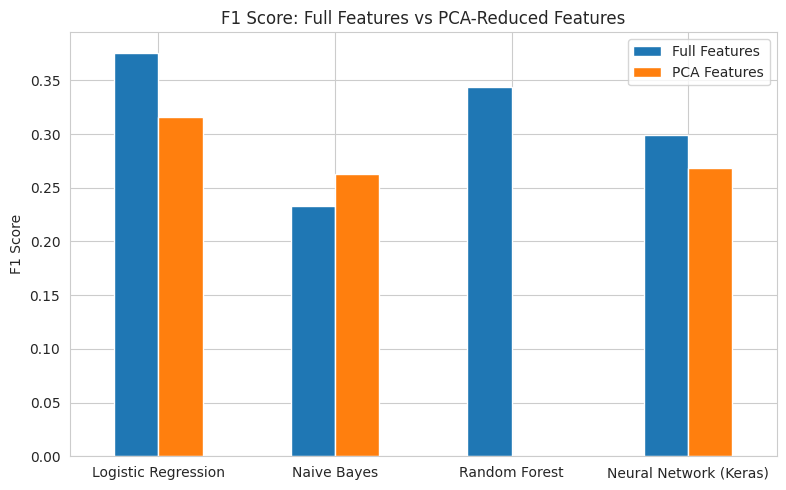

In [71]:
pca_eval_results = {}

pca_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
}

for name, model_template in pca_models.items():
    model_template.fit(X_train_pca, y_train)
    pred = model_template.predict(X_test_pca)
    proba = model_template.predict_proba(X_test_pca)[:, 1]
    pca_eval_results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'AUC': roc_auc_score(y_test, proba)
    }

nn_pca_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_pca_model.compile(optimizer=Adam(learning_rate=0.001), loss=BinaryCrossentropy(), metrics=['accuracy'])
nn_pca_model.fit(X_train_pca, y_train, validation_split=0.15, epochs=60, batch_size=32,
                  class_weight=class_weight, verbose=0)

nn_pca_proba = nn_pca_model.predict(X_test_pca, verbose=0).ravel()
nn_pca_pred = (nn_pca_proba >= 0.5).astype(int)
pca_eval_results['Neural Network (Keras)'] = {
    'Accuracy': accuracy_score(y_test, nn_pca_pred),
    'Precision': precision_score(y_test, nn_pca_pred),
    'Recall': recall_score(y_test, nn_pca_pred),
    'F1 Score': f1_score(y_test, nn_pca_pred),
    'AUC': roc_auc_score(y_test, nn_pca_proba)
}

pca_results_df = pd.DataFrame(pca_eval_results).T
print("Full-feature results:")
print(results_df.round(3))
print("\nPCA-reduced-feature results:")
print(pca_results_df.round(3))
save_table(pca_results_df, 'pca_model_comparison_results.csv')

fig = plt.figure(figsize=(8,5))
comparison = pd.concat(
    {'Full Features': results_df['F1 Score'], 'PCA Features': pca_results_df['F1 Score']}, axis=1
)
comparison.plot(kind='bar', ax=plt.gca(), title='F1 Score: Full Features vs PCA-Reduced Features')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, '14_pca_vs_full_f1_comparison.png')
plt.show()

## 7. Testing on 10 Synthetic "Current" Employees

Generate 10 fake employees with randomly generated but realistic attribute values (sampled within the ranges seen in the real data), then use every trained model to predict whether each one will stay or leave.

Compare the models' predictions on the same 10 synthetic employees — where they agree, where they disagree, and whether the predicted probability of leaving lines up with intuitive risk factors (e.g. `OverTime = Yes`, low `JobSatisfaction`, low `MonthlyIncome`).

In [72]:
# # Optional: If you are in Colab, you may need to upload test.csv first.
# # Uncomment the following two lines if you want it to prompt you for the file here:
# from google.colab import files
# files.upload()

# # 1. Load the real test dataset
# synth_readable = pd.read_csv('4_test.csv')

# # 2. Keep only the features used during training
# synth_df = synth_readable[feature_cols].copy()

# # 3. Encode categorical features using the encoders fitted in Section 4
# for c in cat_cols:
#     if c in synth_df.columns:
#         synth_df[c] = encoders[c].transform(synth_df[c].astype(str))

# # 4. Scale the features using the scaler fitted in Section 4
# synth_scaled = scaler.transform(synth_df)

# # 5. Generate predictions for each model
# pred_table = synth_readable.copy()
# for name, model in trained.items():
#     if name == 'Neural Network (Keras)':
#         probs = model.predict(synth_scaled, verbose=0).ravel()
#     else:
#         probs = model.predict_proba(synth_scaled)[:, 1]

#     preds = (probs >= 0.5).astype(int)
#     pred_table[f'{name} Prediction'] = np.where(preds == 1, 'Leave', 'Stay')
#     pred_table[f'{name} P(Leave)'] = probs.round(3)

# pd.set_option('display.max_columns', None)
# save_table(pred_table, 'test_csv_predictions.csv')
# pred_table
# 1. Load the real test dataset
synth_readable = pd.read_csv('4_test.csv')

# 2. One-Hot Encode the test data just like we did for the training data
cat_cols_test = synth_readable.select_dtypes(include='object').columns.tolist()
synth_encoded = pd.get_dummies(synth_readable, columns=cat_cols_test, drop_first=True)

# 3. ALIGNMENT (Crucial Step):
# The test set might be missing some categories that existed in the training set.
# This forces the test dataframe to have the exact same columns in the exact same order as training.
# Any missing one-hot columns are automatically added and filled with 0 (False).
synth_encoded = synth_encoded.reindex(columns=feature_cols, fill_value=0)

# 4. Scale the features using the scaler fitted in Section 4
synth_scaled = scaler.transform(synth_encoded)

# 5. Generate predictions for each model
pred_table = synth_readable.copy()
for name, model in trained.items():
    if name == 'Neural Network (Keras)':
        probs = model.predict(synth_scaled, verbose=0).ravel()
    else:
        probs = model.predict_proba(synth_scaled)[:, 1]

    # Check if the model is Random Forest to apply your custom threshold
    if name == 'Random Forest':
        # Change this to whatever the optimal threshold loop outputted!
        threshold = 0.30
        preds = (probs >= threshold).astype(int)
    else:
        preds = (probs >= 0.5).astype(int)

    pred_table[f'{name} Prediction'] = np.where(preds == 1, 'Leave', 'Stay')
    pred_table[f'{name} P(Leave)'] = probs.round(3)

pd.set_option('display.max_columns', None)
save_table(pred_table, 'test_csv_predictions.csv')
pred_table

,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Logistic Regression Prediction,Logistic Regression P(Leave),Naive Bayes Prediction,Naive Bayes P(Leave),Random Forest Prediction,Random Forest P(Leave),Neural Network (Keras) Prediction,Neural Network (Keras) P(Leave)
0,1309,31,Travel_Rarely,1448,Research & Development,3,3,Medical,1,3,Male,81,2,1,Laboratory Technician,3,Single,3875,21086,7,Y,No,11,3,2,80,0,4,6,3,3,2,1,2,1,Leave,0.820,Leave,1.000,Leave,0.34,Stay,0.143
1,1081,35,Travel_Rarely,885,Research & Development,1,2,Medical,1,2,Male,70,3,1,Laboratory Technician,1,Married,2886,18256,1,Y,No,11,3,2,80,0,5,2,4,5,3,1,3,0,Leave,0.769,Leave,1.000,Leave,0.52,Leave,0.947
2,1583,44,Travel_Rarely,836,Research & Development,29,5,Life Sciences,1,3,Male,100,3,2,Laboratory Technician,4,Married,6272,4605,8,Y,No,18,3,3,80,1,8,3,2,5,4,0,4,0,Stay,0.088,Stay,0.262,Stay,0.03,Stay,0.000
3,711,29,Travel_Rarely,1206,Research & Development,7,3,Medical,1,2,Male,89,3,1,Research Scientist,4,Married,2976,11781,1,Y,No,13,3,2,80,0,1,5,3,1,0,0,0,1,Stay,0.318,Leave,0.997,Stay,0.22,Stay,0.048
4,1388,36,Travel_Rarely,949,Research & Development,1,4,Life Sciences,1,2,Male,57,2,3,Manufacturing Director,3,Married,10008,12023,1,Y,No,14,3,4,80,1,10,3,3,10,9,1,9,0,Stay,0.006,Stay,0.000,Stay,0.03,Stay,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,546,27,Travel_Rarely,482,Sales,2,2,Other,1,2,Male,92,3,2,Sales Executive,4,Married,4249,2690,2,Y,Yes,21,4,1,80,1,5,2,2,3,2,0,2,0,Leave,0.523,Stay,0.000,Stay,0.09,Stay,0.003
164,470,33,Travel_Rarely,1245,Research & Development,10,4,Other,1,1,Male,70,4,2,Research Scientist,3,Married,5775,16143,4,Y,No,19,3,2,80,0,10,5,4,7,7,0,2,0,Stay,0.040,Stay,0.000,Stay,0.09,Stay,0.002
165,1244,40,Travel_Rarely,895,Research & Development,20,3,Medical,1,3,Male,52,2,2,Healthcare Representative,4,Married,7978,21534,1,Y,No,13,3,4,80,0,10,2,3,10,7,0,4,0,Stay,0.126,Leave,0.797,Stay,0.16,Stay,0.001
166,515,25,Travel_Frequently,672,Research & Development,1,3,Medical,1,3,Female,96,2,1,Laboratory Technician,4,Married,3730,25308,1,Y,Yes,21,4,4,80,1,7,3,3,7,3,7,6,0,Leave,0.655,Leave,0.974,Stay,0.14,Stay,0.042


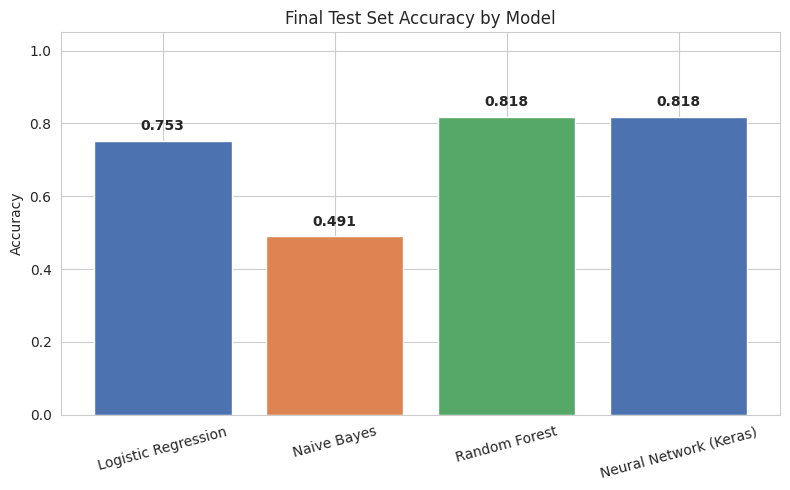

In [73]:
# Create a bar chart specifically for Test Accuracy
fig = plt.figure(figsize=(8, 5))

# Extract just the accuracy column from our results dataframe
accuracies = results_df['Accuracy']
colors = ['#4C72B0', '#DD8452', '#55A868'] # Different colors for each bar

# Plot the bars
bars = plt.bar(accuracies.index, accuracies.values, color=colors[:len(accuracies)])

# Add labels and formatting
plt.title('Final Test Set Accuracy by Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05) # Give a little headroom above 1.0 for labels
plt.xticks(rotation=15)

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '15_final_accuracy_comparison.png')
plt.show()

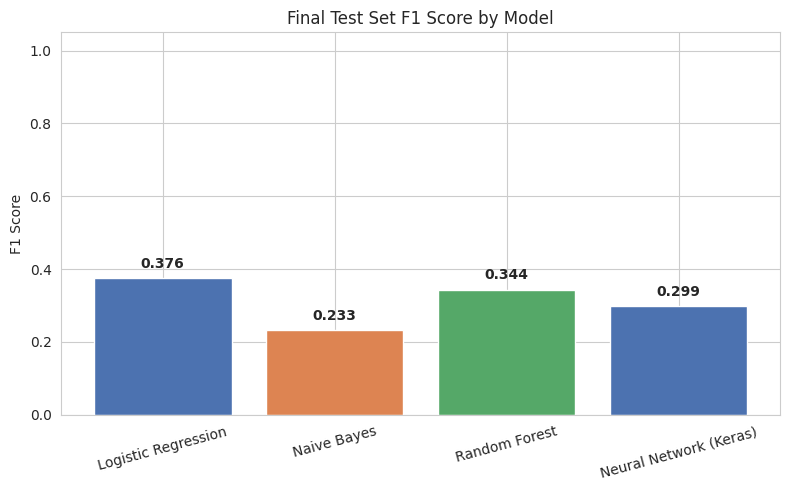

In [74]:
# Create a bar chart specifically for Test F1 Scores
fig = plt.figure(figsize=(8, 5))

# Extract the F1 Score column from our results dataframe
f1_scores = results_df['F1 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

# Plot the bars
bars = plt.bar(f1_scores.index, f1_scores.values, color=colors[:len(f1_scores)])

# Add labels and formatting
plt.title('Final Test Set F1 Score by Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '16_final_f1_comparison.png')
plt.show()

## 8. Conclusion (fill in after running)

- **Best model:** based on the F1 Score and AUC table in Section 6 (prefer these over raw Accuracy, since the dataset is imbalanced — a model that predicts "Stayed" for everyone would still score ~88% accuracy while being useless).
- **Probable reasons:** discuss e.g. Naive Bayes' independence assumption between features vs. Logistic Regression's and the Neural Network's ability to weigh correlated features together; the effect of class weighting; whether the Neural Network out- or under-performed the simpler models, and why; whether PCA (Section 6.2) helped or hurt each model; whether K-Means clusters (Section 6.1) aligned with attrition at all, and why or why not.

*(Once you've run the notebook, send me the printed metrics/plots and I can help you write this section up properly.)*

--- Training Scikit-Learn & Custom Models ---
Logistic Regression trained.
Naive Bayes trained.
Optimal Threshold for Random Forest: 0.50
Random Forest trained.
Batch Gradient Descent trained.

--- Training Neural Network ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network trained.

--- Model Evaluation ---
                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.744      0.265   0.650     0.377  0.772
Naive Bayes                0.679      0.212   0.625     0.316  0.692
Random Forest              0.878      0.484   0.375     0.423  0.771
Batch Gradient Descent     0.744      0.265   0.650     0.377  0.772
Neural Network             0.807      0.295   0.450     0.356  0.740


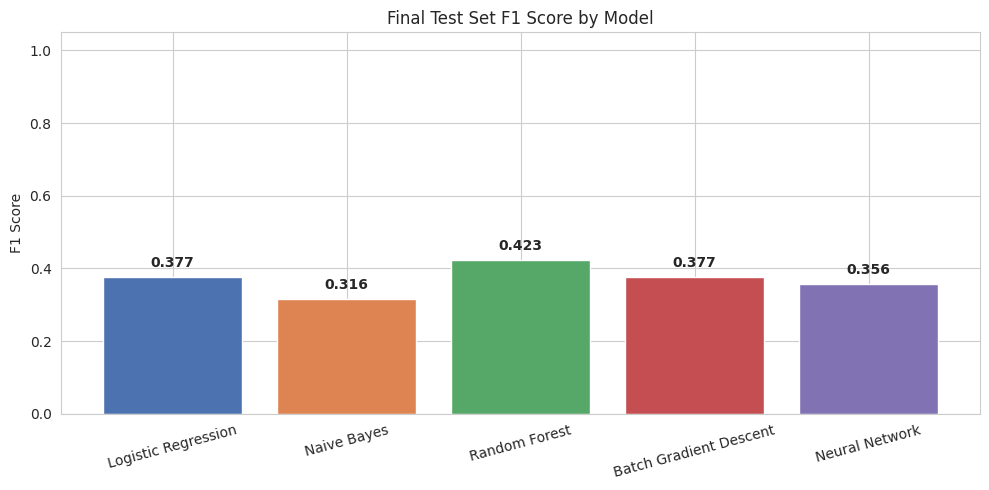

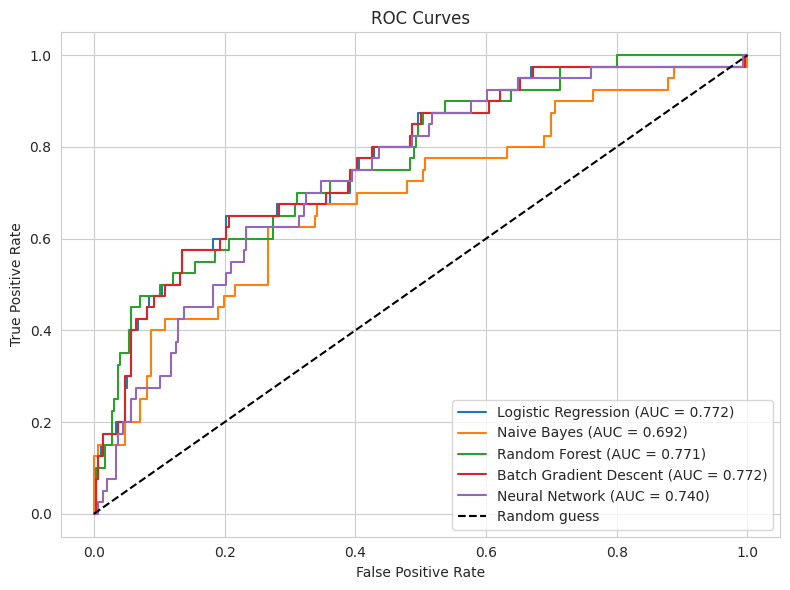


--- Running Predictions on 4_test.csv ---
Predictions saved to 'results/final_test_predictions.csv'.


In [75]:
# 0. Setup and Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Set up output directory for saving files
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style('whitegrid')

def save_fig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    return path

def save_table(df, name):
    path = os.path.join(OUTPUT_DIR, name)
    df.to_csv(path, index=False)
    return path

# ==========================================
# 1. Custom Batch Gradient Descent Class
# ==========================================
class BatchGradientDescent:
    def __init__(self, learning_rate=0.1, epochs=3000):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y, class_weight=None):
        y_arr = y.values if isinstance(y, pd.Series) else y
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.weights = np.zeros(X_b.shape[1])

        weights_array = np.ones(len(y_arr))
        if class_weight == 'balanced':
            ratio = (y_arr == 0).sum() / (y_arr == 1).sum()
            weights_array[y_arr == 1] = ratio

        for _ in range(self.epochs):
            z = np.clip(np.dot(X_b, self.weights), -250, 250)
            predictions = 1 / (1 + np.exp(-z))
            errors = (predictions - y_arr) * weights_array
            gradients = np.dot(X_b.T, errors) / len(y_arr)
            self.weights -= self.lr * gradients
        return self

    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        z = np.clip(np.dot(X_b, self.weights), -250, 250)
        probs = 1 / (1 + np.exp(-z))
        return np.vstack([1 - probs, probs]).T

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

# ==========================================
# 2. Data Loading, Cleaning & One-Hot Encoding
# ==========================================
df = pd.read_csv('4.csv')
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
df_clean = df_clean.dropna().drop_duplicates()

# One-Hot Encoding
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

feature_cols = df_clean.drop(columns=['Attrition']).columns.tolist()
X = df_clean[feature_cols]
y = df_clean['Attrition']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Model Definition & Training
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, class_weight='balanced', random_state=42),
    'Batch Gradient Descent': BatchGradientDescent(learning_rate=0.1, epochs=3000)
}

trained = {}
predictions = {}
probabilities = {}

print("--- Training Scikit-Learn & Custom Models ---")
for name, model in models.items():
    if name == 'Batch Gradient Descent':
        model.fit(X_train_scaled, y_train, class_weight='balanced')
    else:
        model.fit(X_train_scaled, y_train)

    trained[name] = model
    probs = model.predict_proba(X_test_scaled)[:, 1]
    probabilities[name] = probs

    # Threshold Tuning for Random Forest
    if name == 'Random Forest':
        best_f1, best_thresh = 0, 0.5
        for thresh in np.arange(0.1, 0.9, 0.05):
            temp_preds = (probs >= thresh).astype(int)
            temp_f1 = f1_score(y_test, temp_preds)
            if temp_f1 > best_f1:
                best_f1, best_thresh = temp_f1, thresh
        print(f"Optimal Threshold for Random Forest: {best_thresh:.2f}")
        predictions[name] = (probs >= best_thresh).astype(int)
    else:
        predictions[name] = model.predict(X_test_scaled)
    print(f"{name} trained.")

# ==========================================
# 4. Neural Network Training (Mini-Batch)
# ==========================================
print("\n--- Training Neural Network ---")
class_weight_nn = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss=BinaryCrossentropy(), metrics=['accuracy'])
nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, class_weight=class_weight_nn, verbose=0)

nn_proba = nn_model.predict(X_test_scaled, verbose=0).ravel()
trained['Neural Network'] = nn_model
predictions['Neural Network'] = (nn_proba >= 0.5).astype(int)
probabilities['Neural Network'] = nn_proba
print("Neural Network trained.")

# ==========================================
# 5. Evaluation & Graphing
# ==========================================
print("\n--- Model Evaluation ---")
eval_results = {}
for name in predictions:
    eval_results[name] = {
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Precision': precision_score(y_test, predictions[name]),
        'Recall': recall_score(y_test, predictions[name]),
        'F1 Score': f1_score(y_test, predictions[name]),
        'AUC': roc_auc_score(y_test, probabilities[name])
    }

results_df = pd.DataFrame(eval_results).T
print(results_df.round(3))
save_table(results_df, 'final_model_comparison.csv')

# Plot F1 Scores
fig_f1 = plt.figure(figsize=(10, 5))
f1_scores = results_df['F1 Score']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
bars = plt.bar(f1_scores.index, f1_scores.values, color=colors[:len(f1_scores)])
plt.title('Final Test Set F1 Score by Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
save_fig(fig_f1, 'final_f1_comparison.png')
plt.show()

# Plot ROC Curves
fig_roc = plt.figure(figsize=(8, 6))
for name in probabilities:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = eval_results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig_roc, 'final_roc_curves.png')
plt.show()

# ==========================================
# 6. Test on Unseen File (4_test.csv)
# ==========================================
print("\n--- Running Predictions on 4_test.csv ---")
synth_readable = pd.read_csv('4_test.csv')

# One-Hot Encode and Align
cat_cols_test = synth_readable.select_dtypes(include='object').columns.tolist()
synth_encoded = pd.get_dummies(synth_readable, columns=cat_cols_test, drop_first=True)
synth_encoded = synth_encoded.reindex(columns=feature_cols, fill_value=0)

# Scale
synth_scaled = scaler.transform(synth_encoded)

# Predict
pred_table = synth_readable.copy()
for name, model in trained.items():
    if name == 'Neural Network':
        probs = model.predict(synth_scaled, verbose=0).ravel()
    elif name == 'Batch Gradient Descent':
        probs = model.predict_proba(synth_scaled)[:, 1]
    else:
        probs = model.predict_proba(synth_scaled)[:, 1]

    if name == 'Random Forest':
        # Re-using the optimized threshold found during training
        preds = (probs >= best_thresh).astype(int)
    else:
        preds = (probs >= 0.5).astype(int)

    pred_table[f'{name} Prediction'] = np.where(preds == 1, 'Leave', 'Stay')
    pred_table[f'{name} P(Leave)'] = probs.round(3)

save_table(pred_table, 'final_test_predictions.csv')
print("Predictions saved to 'results/final_test_predictions.csv'.")

## 9. Download Results

Everything produced above — every result table (CSV) and every plot (PNG) — has been saved into the `results/` folder as the notebook ran (via the `save_table` / `save_fig` helpers defined in Section 0). Run the cell below any time after running the rest of the notebook to zip that folder and download it as a single file. You can also download files individually from the file browser on the left (📁 icon) inside the `results/` folder.

In [76]:
import shutil
from google.colab import files as colab_files

zip_path = shutil.make_archive('attrition_project_results', 'zip', OUTPUT_DIR)
print(f"Zipped {len(saved_files)} files into {zip_path}")
colab_files.download(zip_path)

Zipped 20 files into /content/attrition_project_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Tip:** if the automatic download prompt is blocked by your browser, open the Colab file browser (folder icon on the left sidebar), find `attrition_project_results.zip` in the file list, and click the three-dot menu → Download.